In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [8]:
import re

def extract_maxerr(log_file_path):
    """
    Extract the maxerr value from a log file.
    
    Args:
        log_file_path: Path to the log file
        
    Returns:
        float: The maxerr value, or None if not found
    """
    pattern = r'maxerr\s*=\s*([\d.eE+-]+)'
    
    with open(log_file_path, 'r') as f:
        # Read from the end of the file for efficiency
        lines = f.readlines()
        
        # Search backwards through the last ~20 lines
        for line in reversed(lines[-20:]):
            match = re.search(pattern, line)
            if match:
                return float(match.group(1))
    
    return None

In [9]:
def extract_velocity(velocity_file_path):
    """
    Extract the velocity data from a .npz file.
    
    Args:
        velocity_file_path: Path to the .npz file
    Returns:
        np.ndarray: The velocity data, or None if not found
        maxerr: The maxerr value extracted from the corresponding log file
    """
    if not os.path.exists(velocity_file_path):
        print(f"Velocity file {velocity_file_path} does not exist.")
        return None, None
    
    velocity_data = np.load(velocity_file_path)['drift3d']
    
    # Construct the corresponding log file path
    log_file_path = '/'.join(velocity_file_path.split('/')[:-2]) + '/pochoir.log'
    
    maxerr = extract_maxerr(log_file_path)
    
    # get efield
    path_to_efield = '/'.join(velocity_file_path.split('/')[:-2]) + '/velocity/efield.npz'
    efield = np.load(path_to_efield)['efield']/1e-6
    return velocity_data, maxerr, efield

In [4]:
list_steps = [1300, 2600, 3900, 5000, 10000, 50_000, 100_000]
list_steps = [100_000, 500_000, '1M']
# list_steps = [500_000, '1M']

In [5]:
speed_unit = 0.001

efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 1.69e-03
efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 5.59e-05
efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 8.33e-07


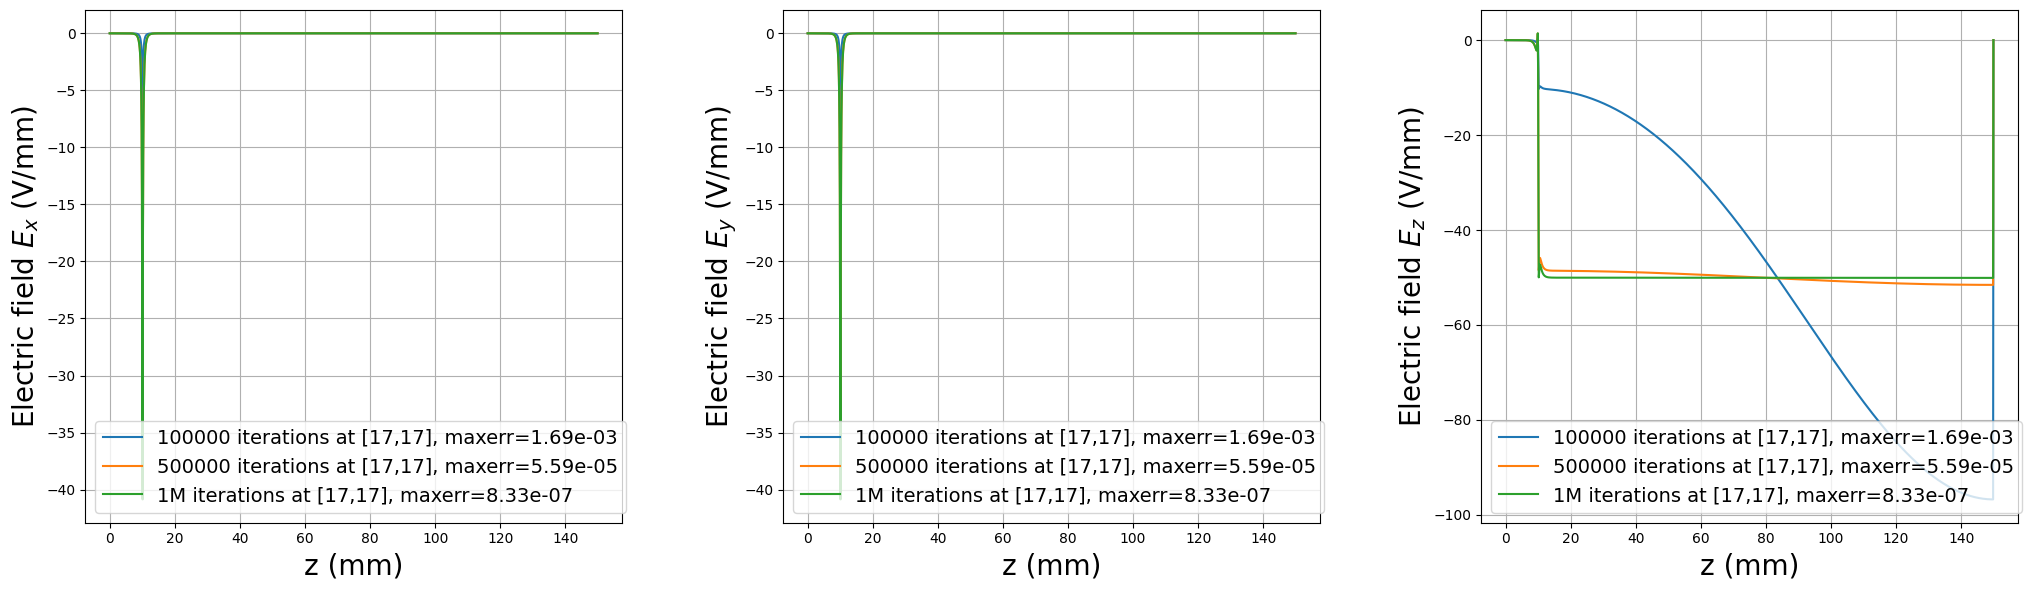

In [25]:
list_velocities = []
for steps in list_steps:
    path_to_velocity_file = f'../store_{steps}steps/velocity/drift3d.npz'
    velocity_data, maxerr, efield = extract_velocity(path_to_velocity_file)
    list_velocities.append((velocity_data, maxerr, efield))
for i, (velocity_data, maxerr, efield) in enumerate(list_velocities):
    print(f'efield shape: {efield.shape}, velocity shape: {velocity_data.shape}, maxerr: {maxerr:.2e}')
# plt.figure(figsize=(10, 6))
axes  = ['x', 'y', 'z']
fig, ax = plt.subplots(1,3, figsize=(21, 6))
for j in range(3):
    for i, (velocity_data, maxerr, efield) in enumerate(list_velocities):
        # ax[j].plot(np.arange(velocity_data.shape[3])*0.1, velocity_data[j, 17,17,:]/speed_unit, label=f'{list_steps[i]} iterations at [17,17], maxerr={maxerr:.2e}')
        ax[j].plot(np.arange(efield.shape[3])*0.1, efield[j, 17,17,:], label=f'{list_steps[i]} iterations at [17,17], maxerr={maxerr:.2e}')
    ax[j].set_xlabel('z (mm)', fontsize=20)
    # ax[j].set_ylabel(f'Drift velocity $v_{axes[j]}$ (mm/us)', fontsize=20)
    ax[j].set_ylabel(f'Electric field $E_{axes[j]}$ (V/mm)', fontsize=20)
    ax[j].grid(True)
    # ax[j].set_ylabel('Electric field $E_z$ (V/mm)', fontsize=20)
    # ax[j].set_xticks(fontsize=20)
    # ax[j].set_xticks(fontsize=20)
    # ax[j].set_yticks(fontsize=20)
    ax[j].legend(fontsize=14)
# plt.ylim([0, -100])
plt.tight_layout()
plt.show()

In [10]:
v0 = np.load('../store_1Msteps_allFloat64/velocity/efield.npz')['efield']
v1 = np.load('../store/velocity/efield.npz')['efield']
# v2 = np.load('../store_1Msteps_allFloat32/velocity/efield.npz')['efield']
# v3 = np.load('../store_1Msteps_allFloat32_nonZeroArr/velocity/efield.npz')['efield']
# v4 = np.load('../store_10000steps/velocity/drift3d.npz')['drift3d']

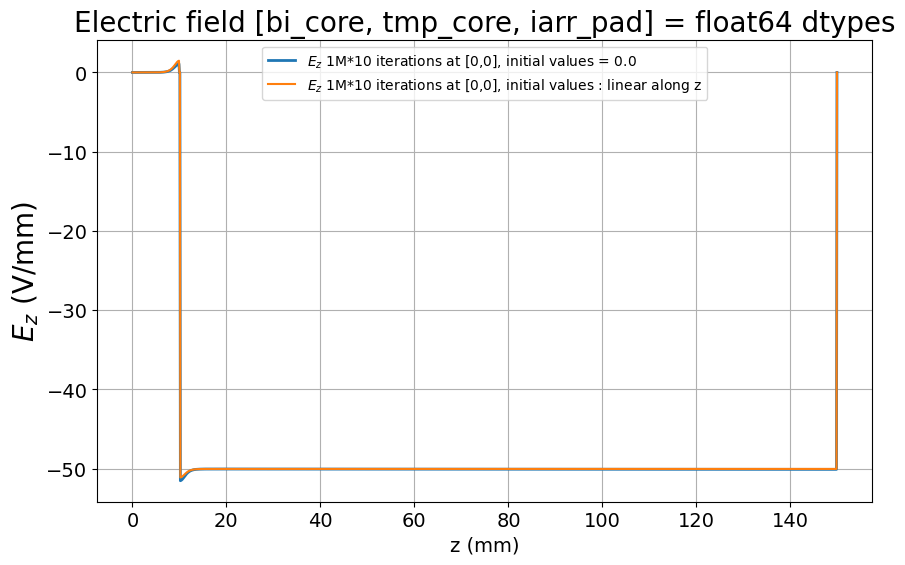

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(v0.shape[3])*0.1, v0[2, 0,0,:]/1e-6, linewidth=2,label=r'$E_z$ 1M*10 iterations at [0,0], initial values = 0.0')
plt.plot(np.arange(v1.shape[3])*0.1, v1[2, 0,0,:]/1e-6, label=r'$E_z$ 1M*10 iterations at [0,0], initial values : linear along z')
# plt.plot(np.arange(v2.shape[3])*0.1, v2[2, 0,0,:]/1e-6, 'c--', label=r'$E_z$ 1M*10 iterations at [0,0], [float32, float32, float32]')
# plt.plot(np.arange(v3.shape[3])*0.1, v3[2, 0,0,:]/1e-6, 'm--', label=r'$E_z$ 1M*10 iterations at [0,0], [float32, float32, float32, non zero iarr]')
# plt.plot(np.arange(v2.shape[3])*0.1, v2[2, 0,0,:], label=r'$v_z$ 3900 iterations at [0,0]')
# plt.plot(np.arange(v3.shape[3])*0.1, v3[2, 0,0,:], label=r'$v_z$ 5000 iterations at [0,0]')
# plt.plot(np.arange(v4.shape[3])*0.1, v4[2, 0,0,:], label=r'$v_z$ 10000 iterations at [0,0]')
plt.xlabel('z (mm)', fontsize=14)
plt.ylabel(r'$E_z$ (V/mm)', fontsize=20)
plt.title("Electric field [bi_core, tmp_core, iarr_pad] = float64 dtypes", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim([7,12])
plt.grid(True)
plt.legend()

In [12]:
path_to_inital_values = '../store/initial/drift3d.npz'
iarr = np.load(path_to_inital_values)['drift3d']
print(f'iarr shape: {iarr.shape}, iarr dtype: {iarr.dtype}')

iarr shape: (44, 44, 1500), iarr dtype: float64


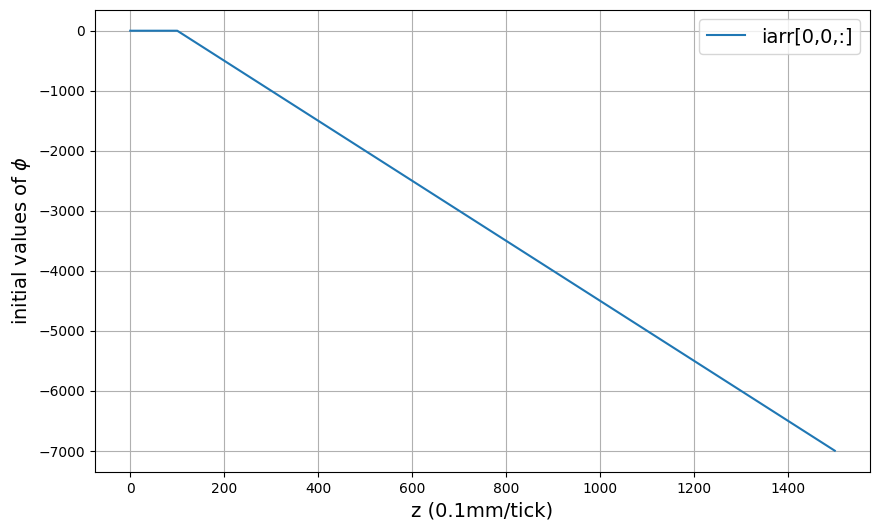

In [13]:
plt.figure(figsize=(10, 6))
# for i in range(5):
#     plt.plot(np.arange(iarr.shape[2]), iarr[i, i,:], label=f'iarr[{i},{i},:]')
plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:], label=r'iarr[0,0,:]')
plt.xlabel('z (0.1mm/tick)', fontsize=14)
plt.ylabel(r'initial values of $\phi$', fontsize=14)
plt.grid(True)
# plt.xlim(0, 200)
# plt.ylim(-200, 1)
plt.legend(fontsize=14)
plt.show()


In [14]:
potential_file_path = '../store/potential/drift3d.npz'
potential = np.load(potential_file_path)['drift3d']
print(f'potential shape: {potential.shape}, potential dtype: {potential.dtype}')

potential shape: (44, 44, 1500), potential dtype: float64


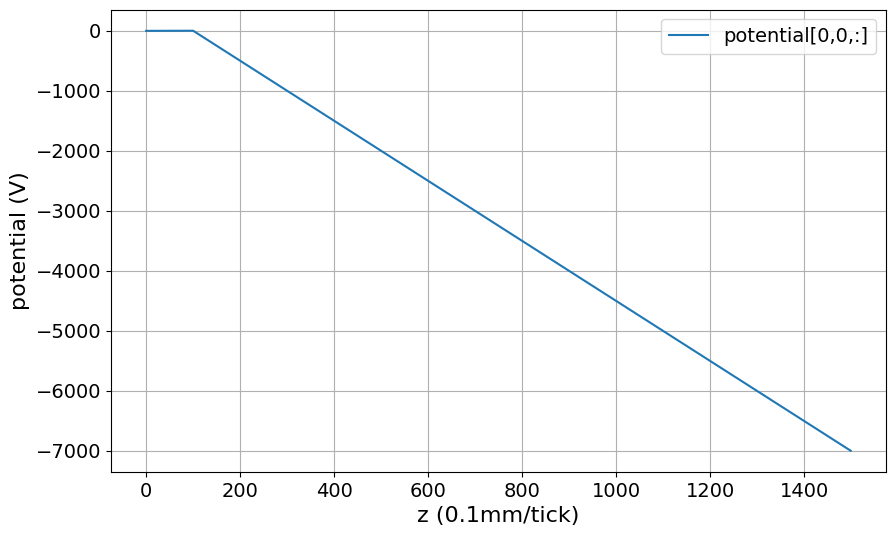

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(potential.shape[2]), potential[0,0,:], label='potential[0,0,:]')
# plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:], label=r'iarr[0,0,:]')
plt.xlabel('z (0.1mm/tick)', fontsize=16)
plt.ylabel('potential (V)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.show()

In [18]:

path_to_err = '../store/increment/drift3d.npz'
err_data = np.load(path_to_err)['drift3d']


In [19]:
np.max(np.abs(err_data))

1.2814780347980559e-08

In [20]:
err_data

array([[[-9.12869780e-12, -9.12869780e-12, -9.12914189e-12, ...,
         -5.63886715e-11, -2.91038305e-11,  0.00000000e+00],
        [-9.12869780e-12, -9.12869780e-12, -9.12914189e-12, ...,
         -5.63886715e-11, -2.91038305e-11,  0.00000000e+00],
        [-9.12958598e-12, -9.12869780e-12, -9.12958598e-12, ...,
         -5.63886715e-11, -2.91038305e-11,  0.00000000e+00],
        ...,
        [-9.12958598e-12, -9.12914189e-12, -9.12825371e-12, ...,
         -5.63886715e-11, -2.91038305e-11,  0.00000000e+00],
        [-9.12914189e-12, -9.12869780e-12, -9.12914189e-12, ...,
         -5.63886715e-11, -2.91038305e-11,  0.00000000e+00],
        [-9.12869780e-12, -9.12869780e-12, -9.12914189e-12, ...,
         -5.63886715e-11, -2.91038305e-11,  0.00000000e+00]],

       [[-9.12869780e-12, -9.12869780e-12, -9.12869780e-12, ...,
         -5.63886715e-11, -2.91038305e-11,  0.00000000e+00],
        [-9.12914189e-12, -9.12869780e-12, -9.12869780e-12, ...,
         -5.63886715e-11, -2.91038305e